In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

In [9]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [24]:
def build_model(pooling_type="max", dropout_rate=0.5,
                kernel_size=3, stride=1, depth=[32, 64, 128]):

    model = models.Sequential()

    model.add(layers.Conv2D(
        depth[0], kernel_size,
        strides=stride,
        padding="same",
        activation='relu',
        input_shape=(28,28,1)
    ))

    if pooling_type == "max":
        model.add(layers.MaxPooling2D(pool_size=(2,2)))
    else:
        model.add(layers.AveragePooling2D(pool_size=(2,2)))

    model.add(layers.Conv2D(
        depth[1], kernel_size,
        strides=stride,
        padding="same",
        activation='relu'
    ))

    if pooling_type == "max":
        model.add(layers.MaxPooling2D(pool_size=(2,2)))
    else:
        model.add(layers.AveragePooling2D(pool_size=(2,2)))

    model.add(layers.Conv2D(
        depth[2], kernel_size,
        strides=stride,
        padding="same",
        activation='relu'
    ))

    model.add(layers.Flatten())

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [17]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f"Accuracy - {title}")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f"Loss - {title}")
    plt.legend()

    plt.show()

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6012 - loss: 1.0579 - val_accuracy: 0.8314 - val_loss: 0.4536
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8271 - loss: 0.4700 - val_accuracy: 0.8672 - val_loss: 0.3618
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8603 - loss: 0.3775 - val_accuracy: 0.8750 - val_loss: 0.3330
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8828 - loss: 0.3263 - val_accuracy: 0.8895 - val_loss: 0.3003
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8949 - loss: 0.2847 - val_accuracy: 0.8930 - val_loss: 0.2879
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9025 - loss: 0.2643 - val_accuracy: 0.9027 - val_loss: 0.2686
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9114 - loss: 0.2393 - val_accuracy: 0.9047 - val_loss: 0.2616
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9168 - loss: 0.2240 - val_accuracy: 0.

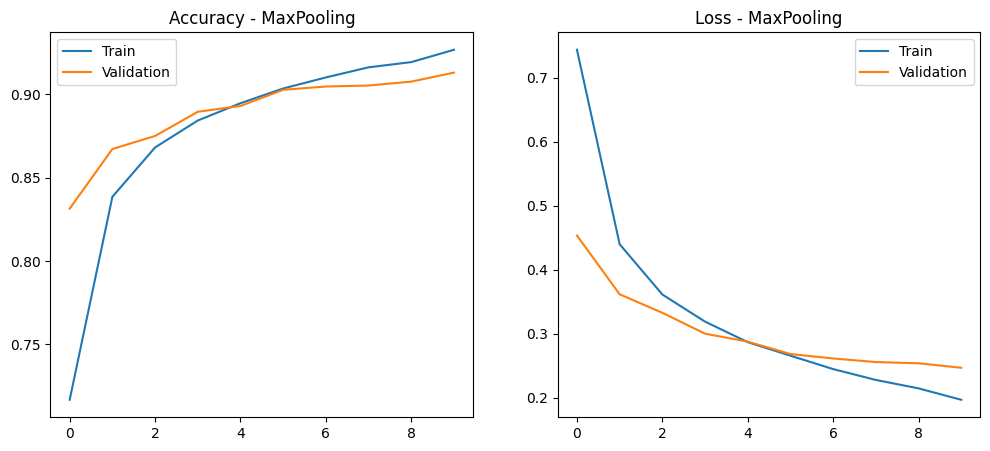

In [19]:
model_max = build_model(pooling_type="max")

history_max = model_max.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_max, "MaxPooling")


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6008 - loss: 1.0779 - val_accuracy: 0.8052 - val_loss: 0.5005
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8034 - loss: 0.5175 - val_accuracy: 0.8404 - val_loss: 0.4261
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8370 - loss: 0.4396 - val_accuracy: 0.8543 - val_loss: 0.3895
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8547 - loss: 0.3908 - val_accuracy: 0.8712 - val_loss: 0.3523
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8671 - loss: 0.3511 - val_accuracy: 0.8800 - val_loss: 0.3262
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8812 - loss: 0.3299 - val_accuracy: 0.8830 - val_loss: 0.3096
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8869 - loss: 0.3037 - val_accuracy: 0.8824 - val_loss: 0.3104
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8951 - loss: 0.2832 - val_accuracy: 0.

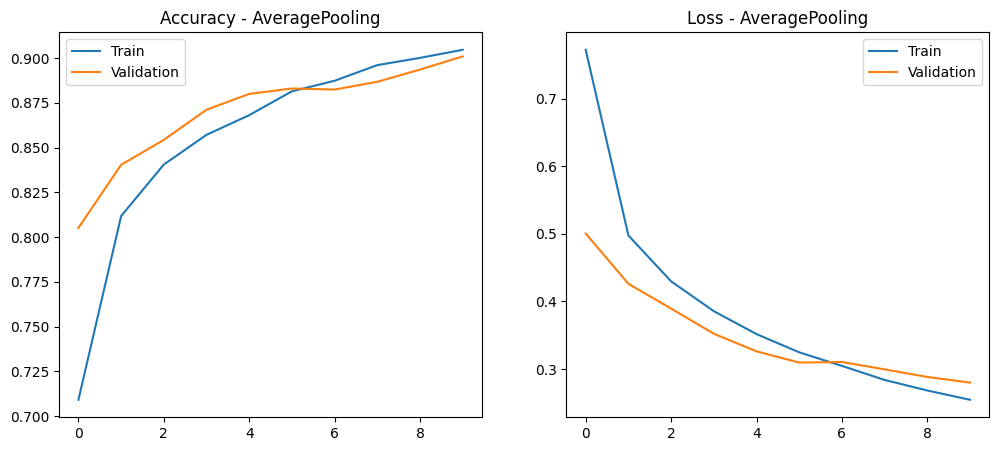

In [20]:
model_avg = build_model(pooling_type="avg")

history_avg = model_avg.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_avg, "AveragePooling")


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.6259 - loss: 0.9790 - val_accuracy: 0.8311 - val_loss: 0.4406
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8384 - loss: 0.4343 - val_accuracy: 0.8670 - val_loss: 0.3505
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8767 - loss: 0.3403 - val_accuracy: 0.8823 - val_loss: 0.3209
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8914 - loss: 0.2949 - val_accuracy: 0.8960 - val_loss: 0.2895
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9042 - loss: 0.2584 - val_accuracy: 0.8932 - val_loss: 0.2806
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9099 - loss: 0.2438 - val_accuracy: 0.9018 - val_loss: 0.2668
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9193 - loss: 0.2190 - val_accuracy: 0.9001 - val_loss: 0.2700
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9235 - loss: 0.2039 - val_accuracy: 0.

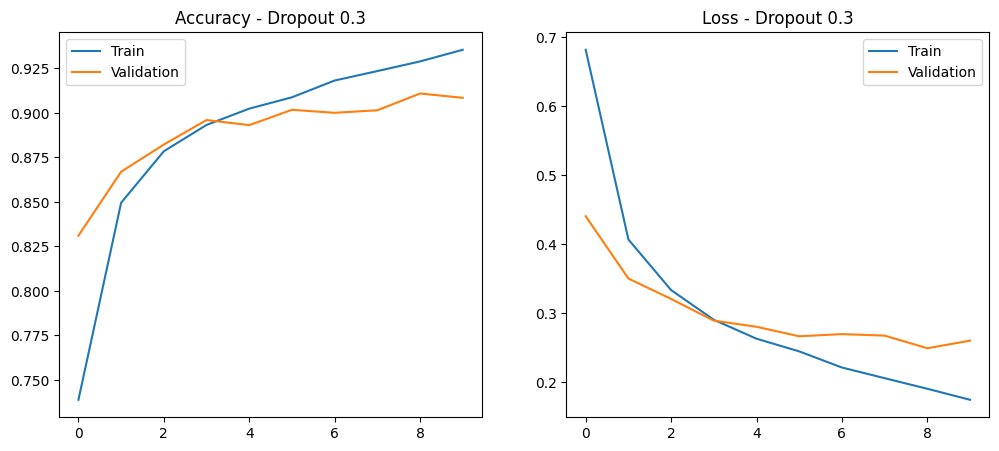

In [21]:
model_d03 = build_model(dropout_rate=0.3)

history_d03 = model_d03.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_d03, "Dropout 0.3")


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5500 - loss: 1.1892 - val_accuracy: 0.8050 - val_loss: 0.4861
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8038 - loss: 0.5246 - val_accuracy: 0.8536 - val_loss: 0.3872
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8404 - loss: 0.4283 - val_accuracy: 0.8713 - val_loss: 0.3491
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8677 - loss: 0.3646 - val_accuracy: 0.8814 - val_loss: 0.3135
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8838 - loss: 0.3216 - val_accuracy: 0.8932 - val_loss: 0.2972
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8921 - loss: 0.2958 - val_accuracy: 0.8947 - val_loss: 0.2833
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9022 - loss: 0.2692 - val_accuracy: 0.9021 - val_loss: 0.2638
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9110 - loss: 0.2487 - val_accuracy: 0.

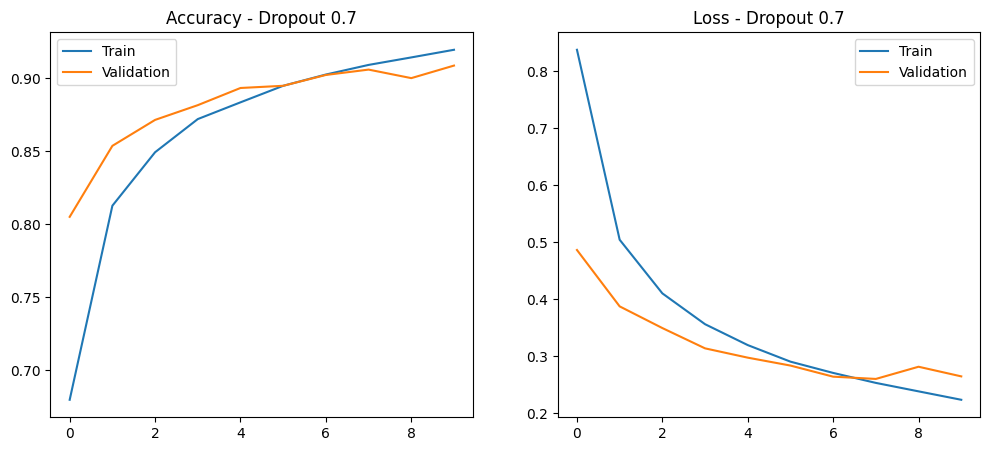

In [22]:
model_d07 = build_model(dropout_rate=0.7)

history_d07 = model_d07.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_d07, "Dropout 0.7")


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6585 - loss: 0.9054 - val_accuracy: 0.8468 - val_loss: 0.4129
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8670 - loss: 0.3690 - val_accuracy: 0.8865 - val_loss: 0.3082
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8941 - loss: 0.2903 - val_accuracy: 0.9007 - val_loss: 0.2668
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9067 - loss: 0.2539 - val_accuracy: 0.9049 - val_loss: 0.2580
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9170 - loss: 0.2212 - val_accuracy: 0.9104 - val_loss: 0.2430
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9254 - loss: 0.1978 - val_accuracy: 0.9128 - val_loss: 0.2458
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9333 - loss: 0.1810 - val_accuracy: 0.9167 - val_loss: 0.2313
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9417 - loss: 0.1563 - val_accuracy: 

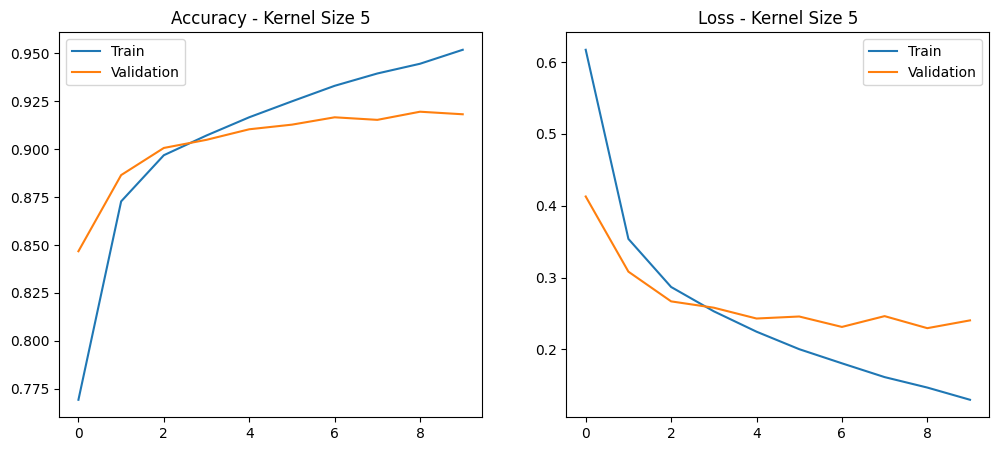

In [25]:
model_k5 = build_model(kernel_size=5)

history_k5 = model_k5.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_k5, "Kernel Size 5")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5333 - loss: 1.2288 - val_accuracy: 0.7830 - val_loss: 0.5481
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8086 - loss: 0.5213 - val_accuracy: 0.8485 - val_loss: 0.4103
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8515 - loss: 0.4097 - val_accuracy: 0.8621 - val_loss: 0.3772
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8724 - loss: 0.3537 - val_accuracy: 0.8723 - val_loss: 0.3483
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8858 - loss: 0.3229 - val_accuracy: 0.8694 - val_loss: 0.3645
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8920 - loss: 0.3038 - val_accuracy: 0.8963 - val_loss: 0.2967
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9026 - loss: 0.2708 - val_accuracy: 0.8848 - val_loss: 0.3262
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9066 - loss: 0.2639 - val_accuracy: 0.

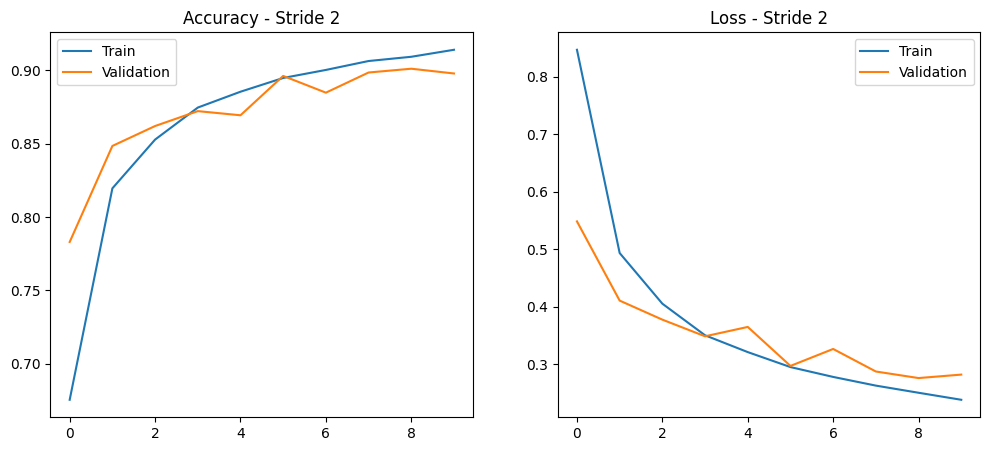

In [26]:
model_s2 = build_model(stride=2)

history_s2 = model_s2.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_s2, "Stride 2")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.6843 - loss: 0.8601 - val_accuracy: 0.8669 - val_loss: 0.3498
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8679 - loss: 0.3668 - val_accuracy: 0.8983 - val_loss: 0.2764
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8945 - loss: 0.2922 - val_accuracy: 0.9070 - val_loss: 0.2631
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9113 - loss: 0.2485 - val_accuracy: 0.9075 - val_loss: 0.2456
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9191 - loss: 0.2237 - val_accuracy: 0.9191 - val_loss: 0.2209
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9274 - loss: 0.2000 - val_accuracy: 0.9223 - val_loss: 0.2121
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9342 - loss: 0.1770 - val_accuracy: 0.9183 - val_loss: 0.2205
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9429 - loss: 0.1568 - val_acc

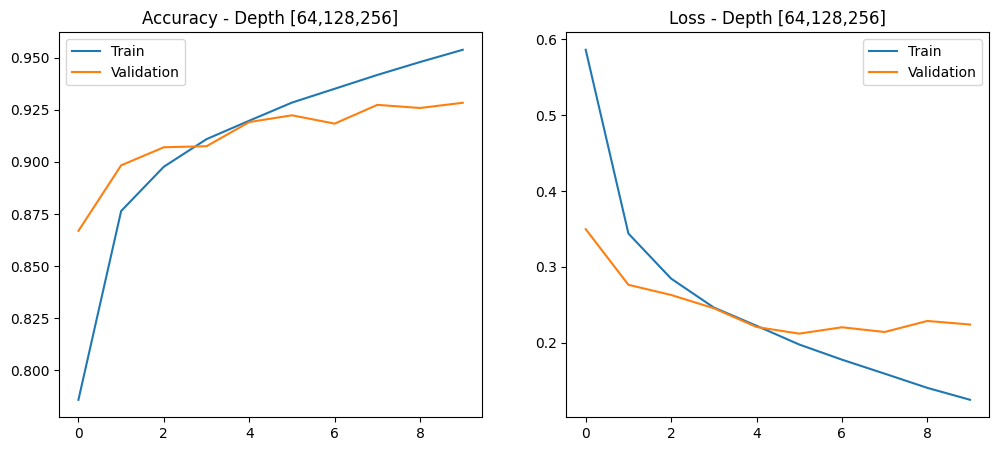

In [27]:
model_deep = build_model(depth=[64, 128, 256])

history_deep = model_deep.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

plot_history(history_deep, "Depth [64,128,256]")

نتیجه‌گیری و تحلیل نمودارها

با توجه به نمودارهای Accuracy و Loss که برای مدل‌های مختلف رسم شد، می‌توان مشاهده کرد که در تمام حالت‌ها، دقت آموزش در طول epochها افزایش یافته و مقدار loss کاهش پیدا کرده است که نشان‌دهنده یادگیری مناسب شبکه است. با این حال، در برخی مدل‌ها فاصله بین دقت آموزش و دقت اعتبارسنجی بیشتر شده که این موضوع می‌تواند نشانه‌ای از overfitting باشد.

در مقایسه بین دو روش MaxPooling و AveragePooling، نتایج نشان می‌دهد که استفاده از MaxPooling باعث افزایش دقت نهایی مدل و همگرایی سریع‌تر آن شده است. در حالی که AveragePooling روند یکنواخت‌تری دارد، اما دقت نهایی آن معمولاً کمتر از حالت MaxPooling است. به همین دلیل، MaxPooling برای این مسئله عملکرد مناسب‌تری داشته است.

بررسی اثر Dropout نشان می‌دهد که استفاده از مقدارهای متوسط باعث بهبود عملکرد مدل در داده‌های اعتبارسنجی می‌شود. در حالتی که مقدار Dropout زیاد انتخاب شده است، دقت آموزش کاهش پیدا کرده و مدل به‌خوبی قادر به یادگیری الگوهای داده نبوده که نشان‌دهنده underfitting است.

همچنین با تغییر اندازه کرنل، مشخص شد که کرنل 3×3 عملکرد بهتری نسبت به کرنل 5×5 دارد. کرنل بزرگ‌تر باعث افزایش پیچیدگی مدل شده و در برخی موارد منجر به کاهش دقت در داده‌های اعتبارسنجی شده است. این موضوع نشان می‌دهد که برای دیتاست Fashion-MNIST، کرنل‌های کوچک‌تر انتخاب مناسب‌تری هستند.

نتایج مربوط به تغییر مقدار Stride نشان داد که افزایش Stride باعث کاهش ابعاد feature map و در نتیجه کاهش دقت مدل می‌شود. در مقابل، استفاده از Stride برابر با 1 باعث حفظ اطلاعات مکانی تصویر و بهبود عملکرد مدل شده است.

در نهایت، بررسی تعداد فیلترها (Depth) نشان داد که افزایش تعداد فیلترها تا حد مشخصی باعث بهبود دقت مدل می‌شود، اما در صورت افزایش بیش از حد، فاصله بین دقت آموزش و اعتبارسنجی بیشتر شده و نشانه‌هایی از overfitting مشاهده می‌شود.

به طور کلی، نتایج این پروژه نشان می‌دهد که انتخاب مناسب معماری شبکه و تنظیم درست هایپرپارامترها نقش مهمی در بهبود عملکرد شبکه‌های کانولوشنی دارد و نمودارهای Accuracy و Loss ابزار مناسبی برای تحلیل رفتار مدل در فرآیند آموزش هستند.